<a href="https://colab.research.google.com/github/ehsankarami1358/LOKA_HYDRO/blob/main/U2_overall_Generator_analyse_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Loaded files:
electric (995, 12)
cool (995, 9)
winding1 (998, 10)
winding2 (999, 10)
core (998, 12)
pad (996, 13)
air (1001, 14)
Merged shape: (995, 74)

Detected winding sensors: 18
['STATOR WINDING PHASE U2 TEMP', 'STATOR WINDING PHASE W14 TEMP', 'STATOR WINDING PHASE V26 TEMP', 'STATOR WINDING PHASE U56 TEMP', 'STATOR WINDING PHASE W68 TEMP', 'STATOR WINDING PHASE V80 TEMP', 'STATOR WINDING PHASE U110 TEMP', 'STATOR WINDING PHASE W122 TEMP', 'STATOR WINDING PHASE V134 TEMP', 'STATOR WINDING PHASE U164 TEMP', 'STATOR WINDING PHASE W176 TEMP', 'STATOR WINDING PHASE V188 TEMP', 'STATOR WINDING PHASE U218 TEMP', 'STATOR WINDING PHASE W230 TEMP', 'STATOR WINDING PHASE V242 TEMP', 'STATOR WINDING PHASE U272 TEMP', 'STATOR WINDING PHASE W284 TEMP', 'STATOR WINDING PHASE V296 TEMP']

Detected core sensors: 4
['STATOR  CORE TEMP', 'STATOR  CORE TEMP.1', 'STATOR  CORE TEMP.2', 'STATOR  CORE TEMP.3']

Detected bearing/pad sensors: 13
['UPPER GUIDE BEARING PAD TEMP', 'UPPER GUIDE BEARING PAD TE

/tmp/ipykernel_10239/2627436466.py:196: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  analysis_df["Winding_Hotspot_Sensor"] = analysis_df[winding_cols].idxmax(axis=1)
/tmp/ipykernel_10239/2627436466.py:200: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  analysis_df["Worst_Winding_Deviation_Sensor"] = temp_dev_abs.idxmax(axis=1)


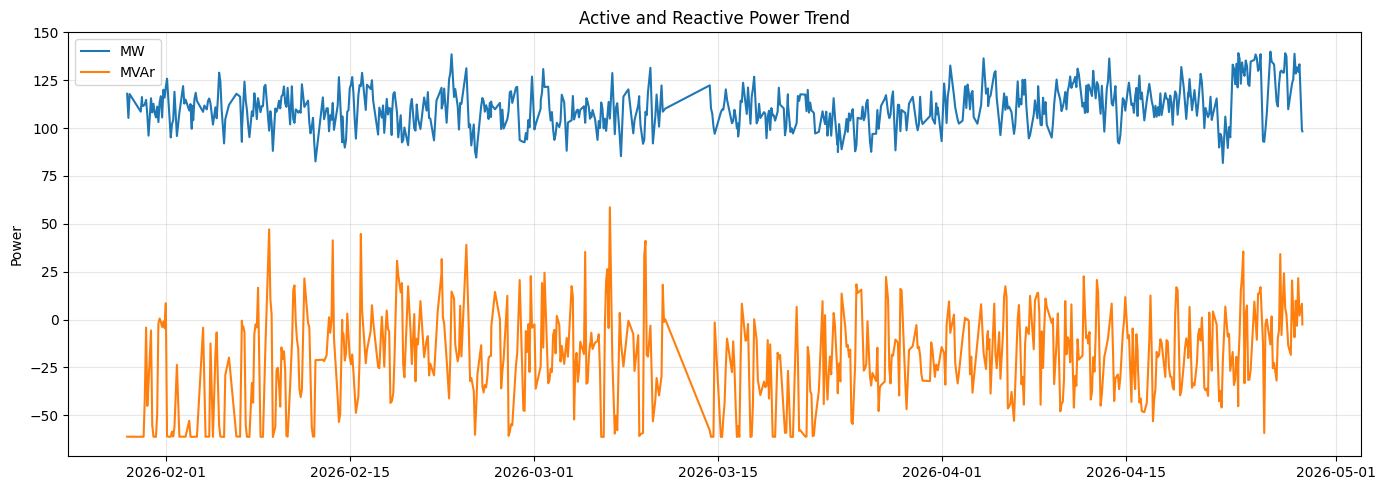

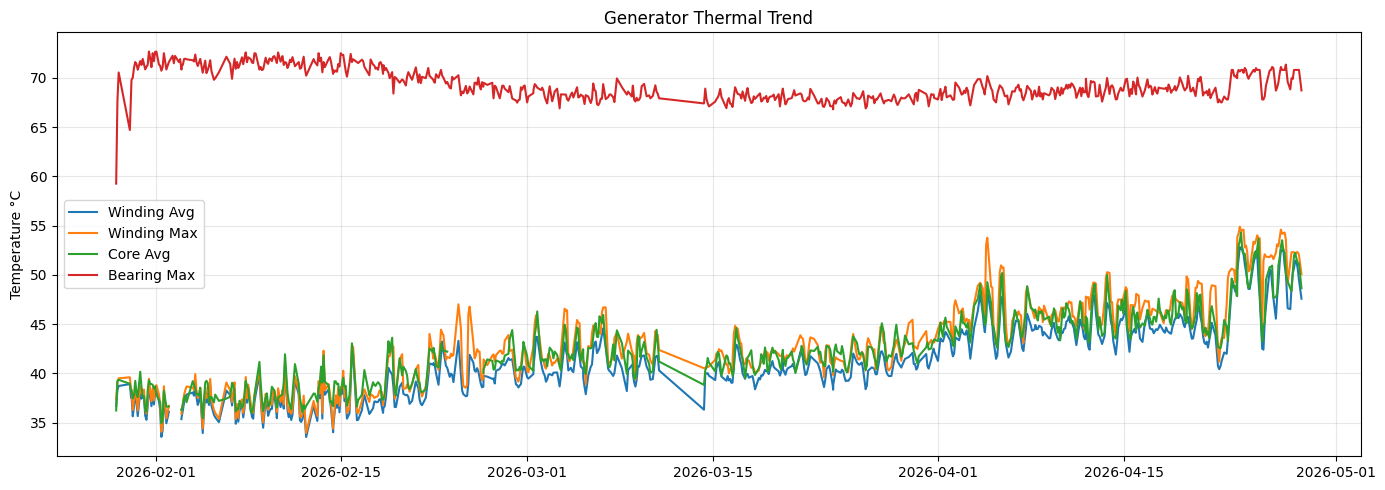

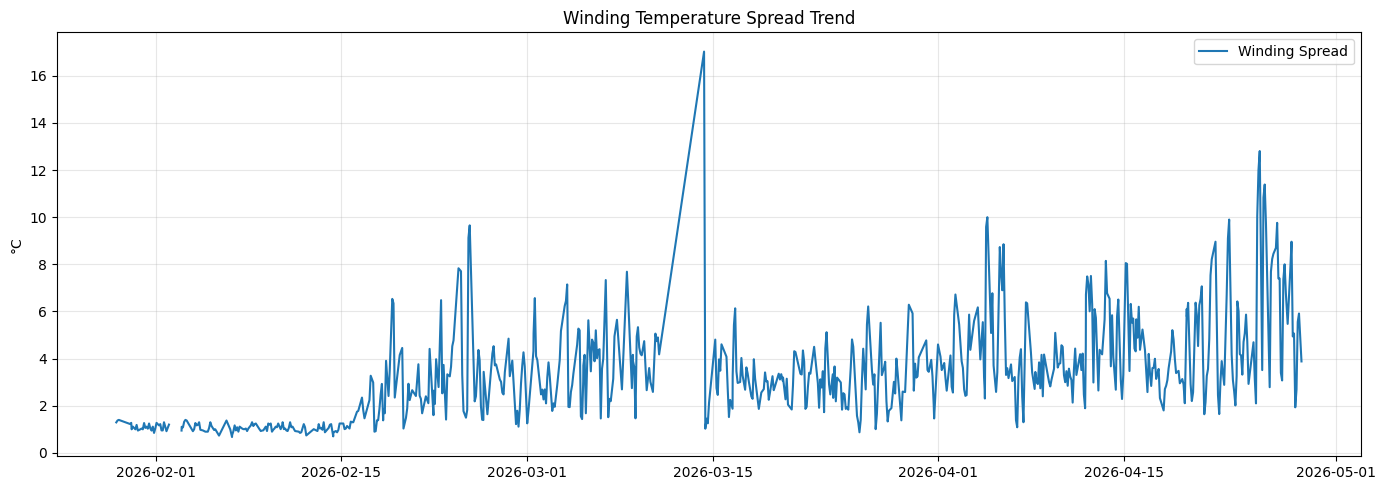

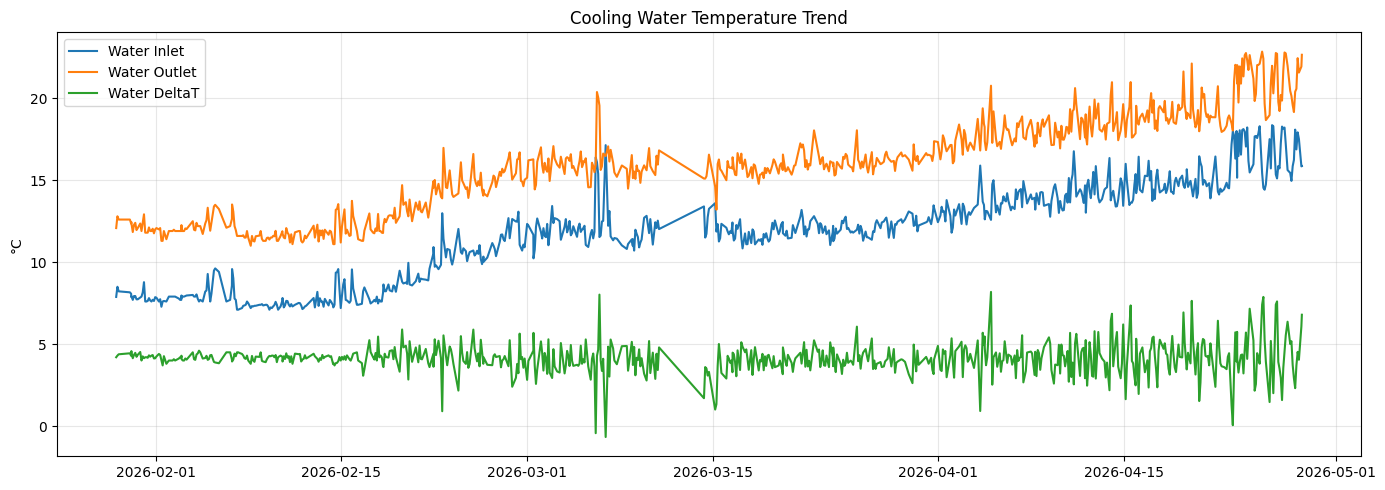

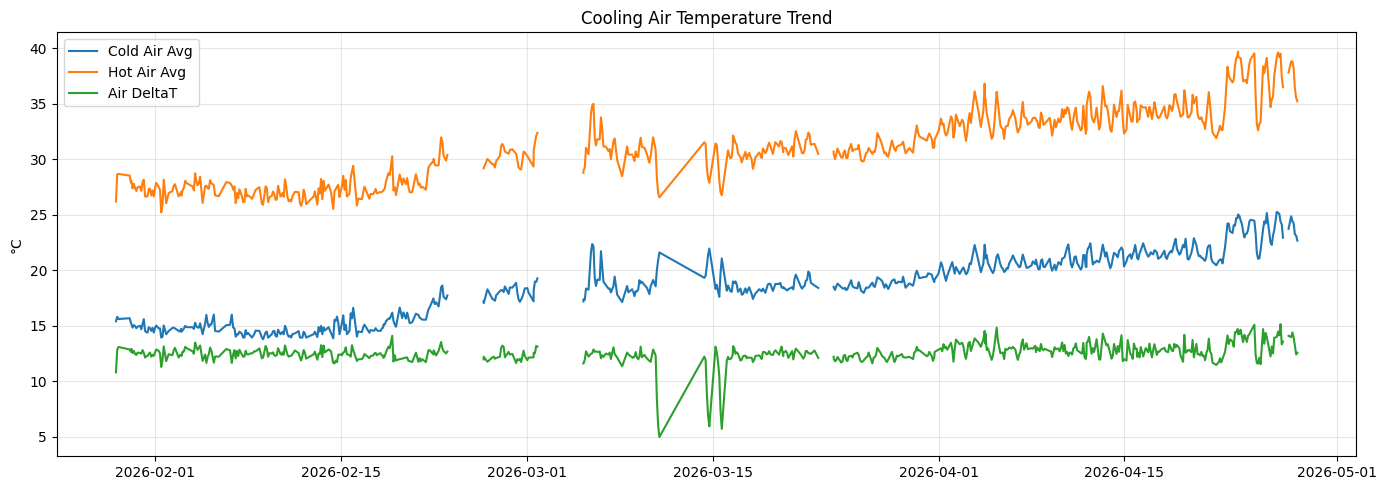

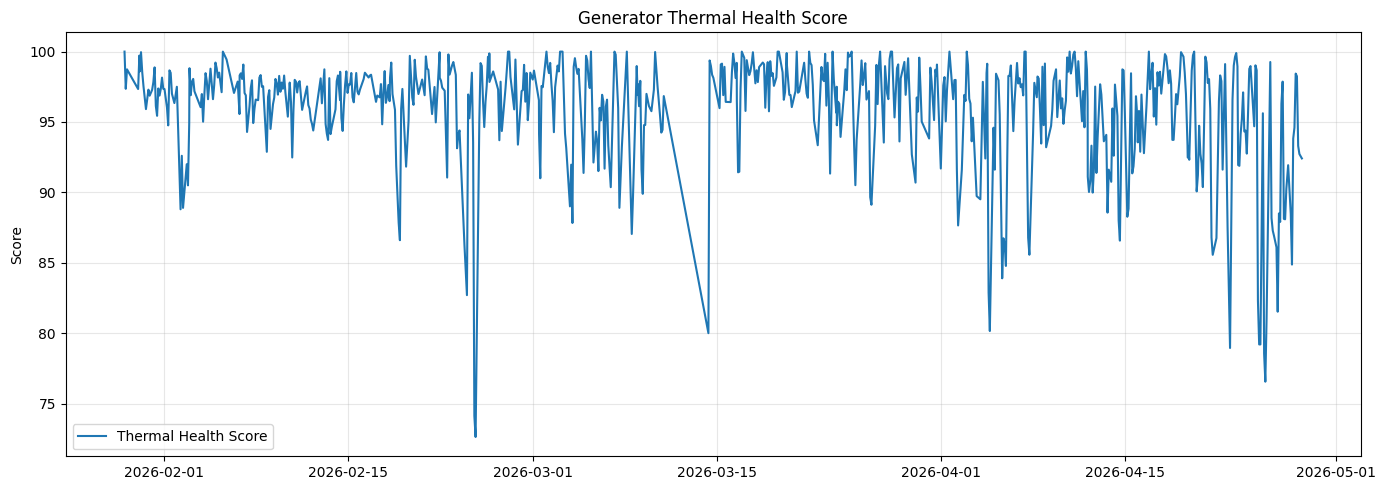

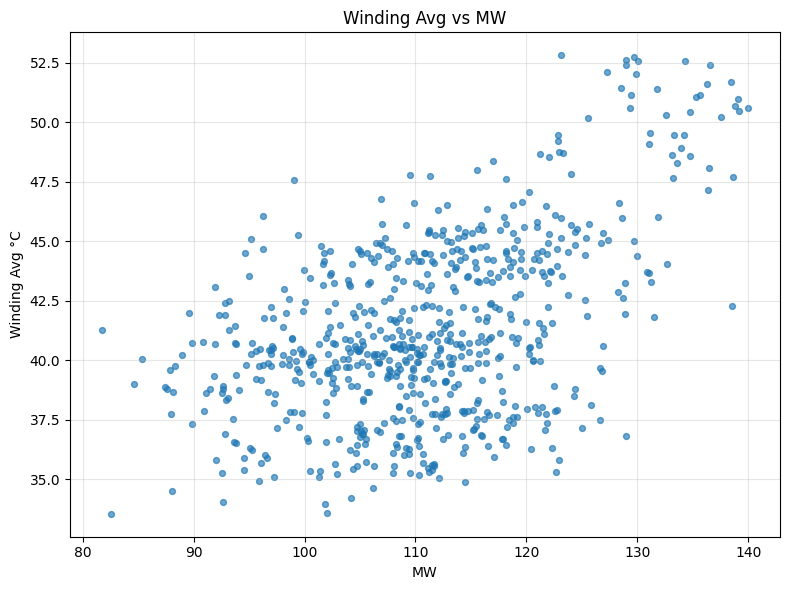

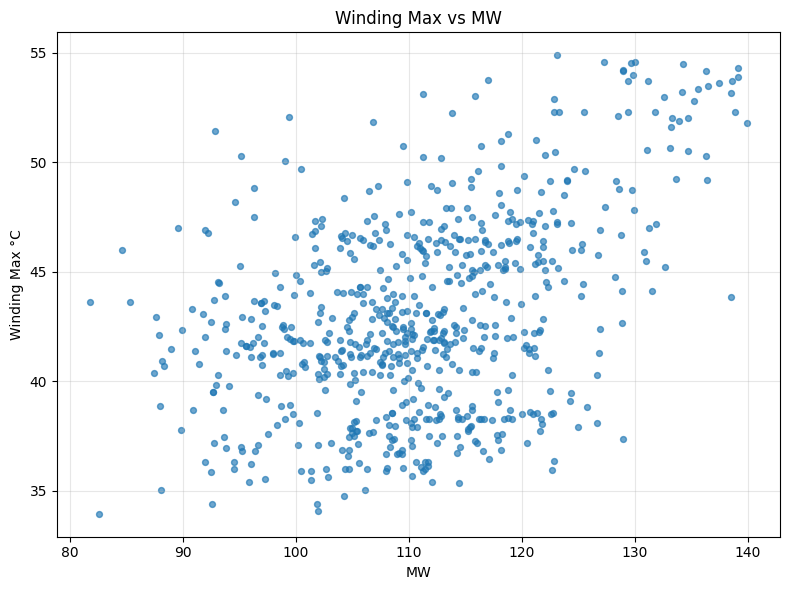

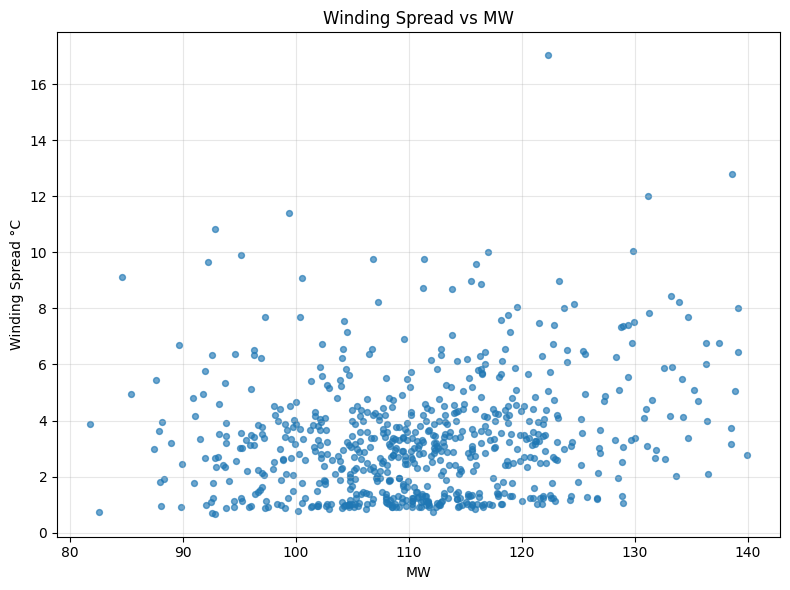

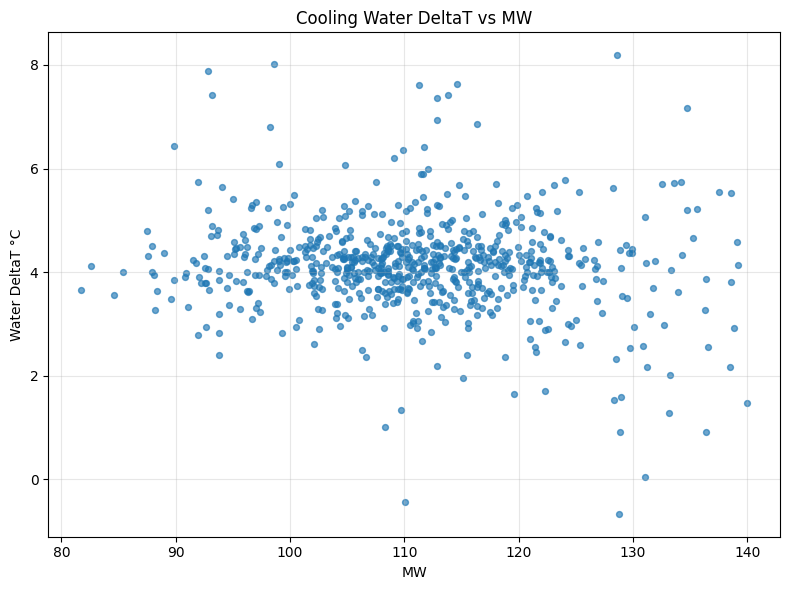

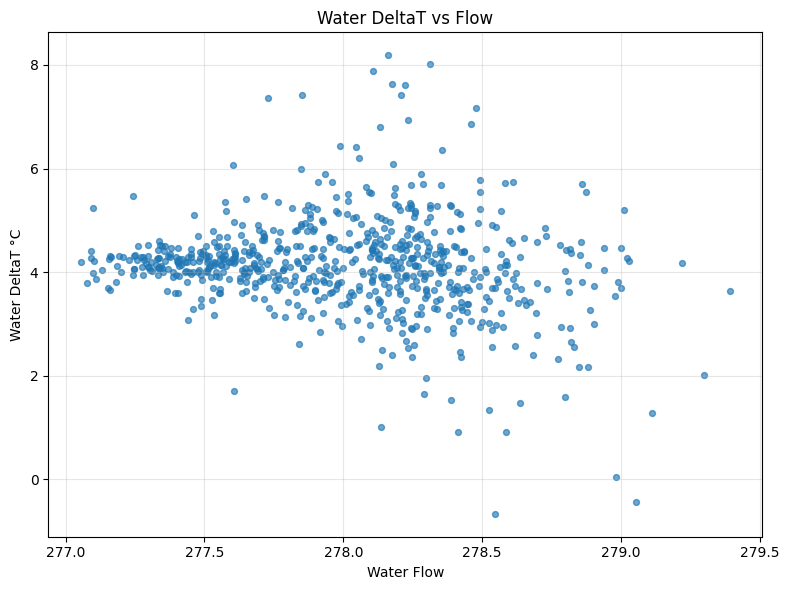

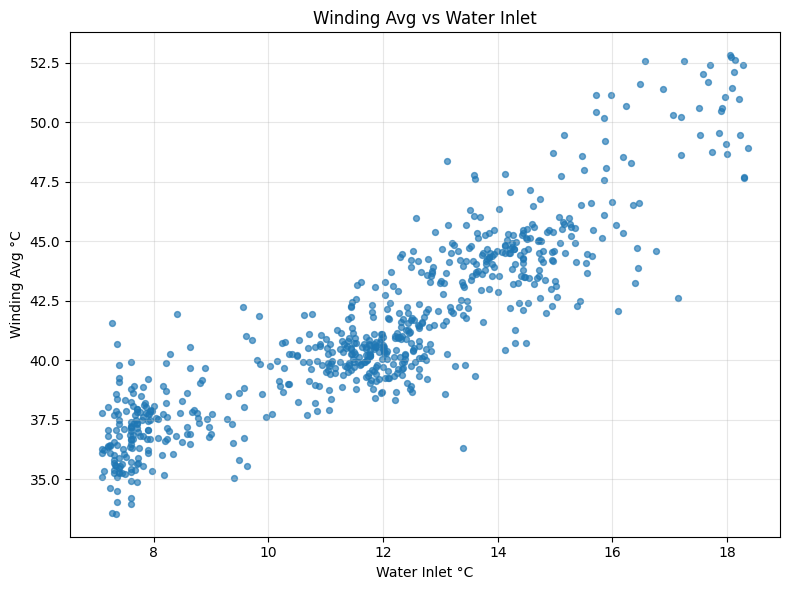

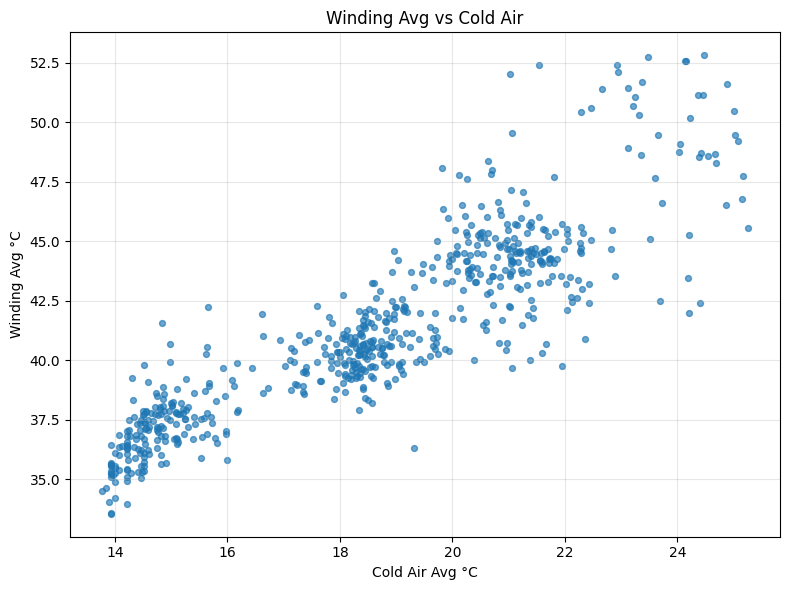

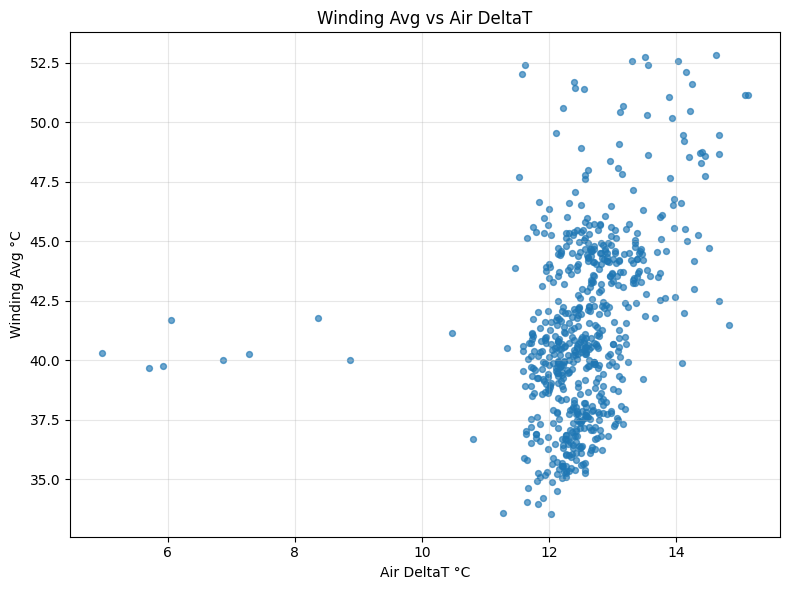

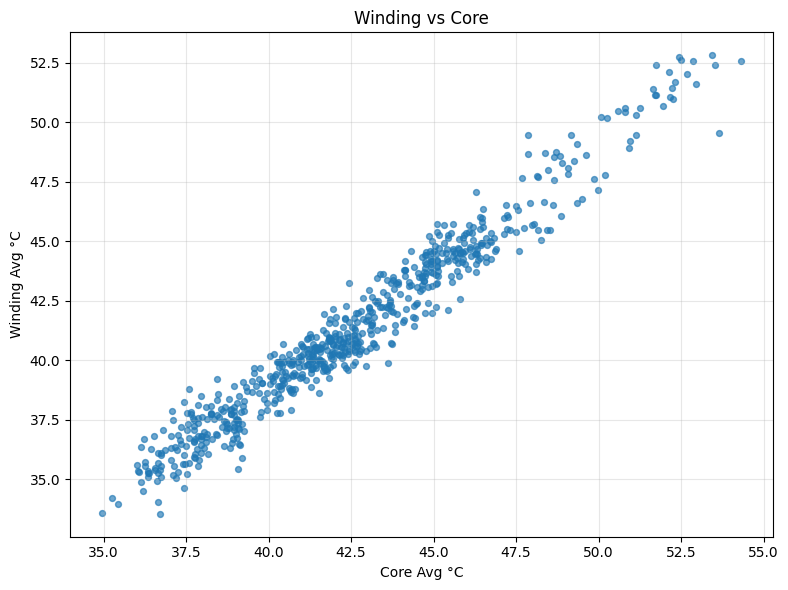

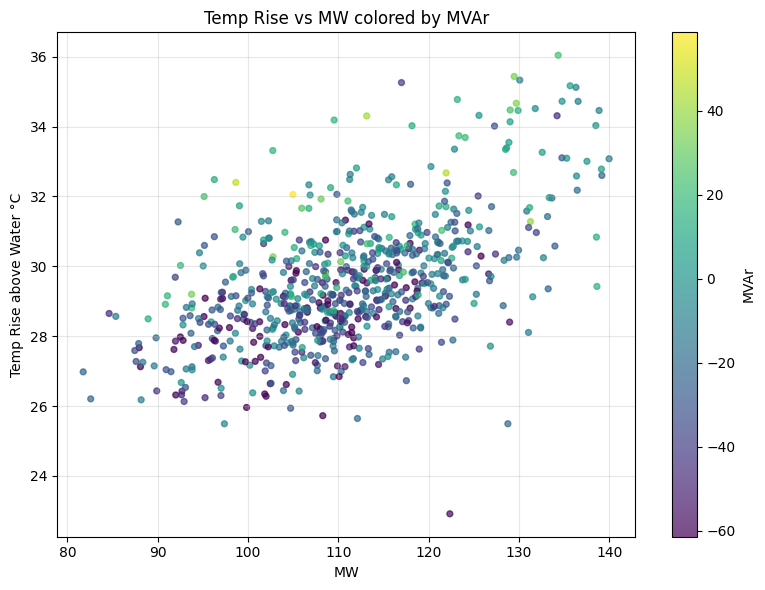

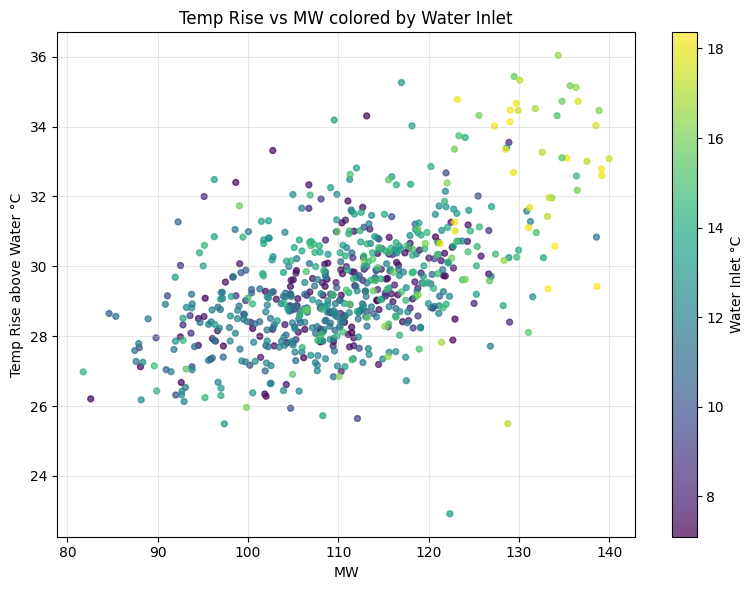

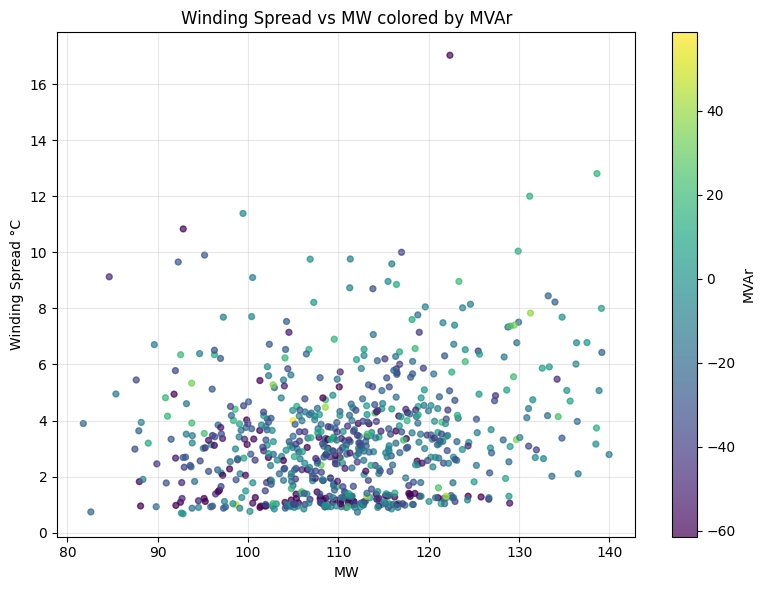


Model performance:
              Model  Train_R2  Test_R2  Train_MAE_C  Test_MAE_C  Train_RMSE_C  \
0  LinearRegression    0.6589   0.5910       0.7025      1.0741        0.9166   
1      RandomForest    0.8309   0.5593       0.4509      1.1296        0.6454   
2           XGBoost    0.9996   0.1205       0.0252      1.4628        0.0333   

   Test_RMSE_C  
0       1.3956  
1       1.4487  
2       2.0465  

Best model: LinearRegression


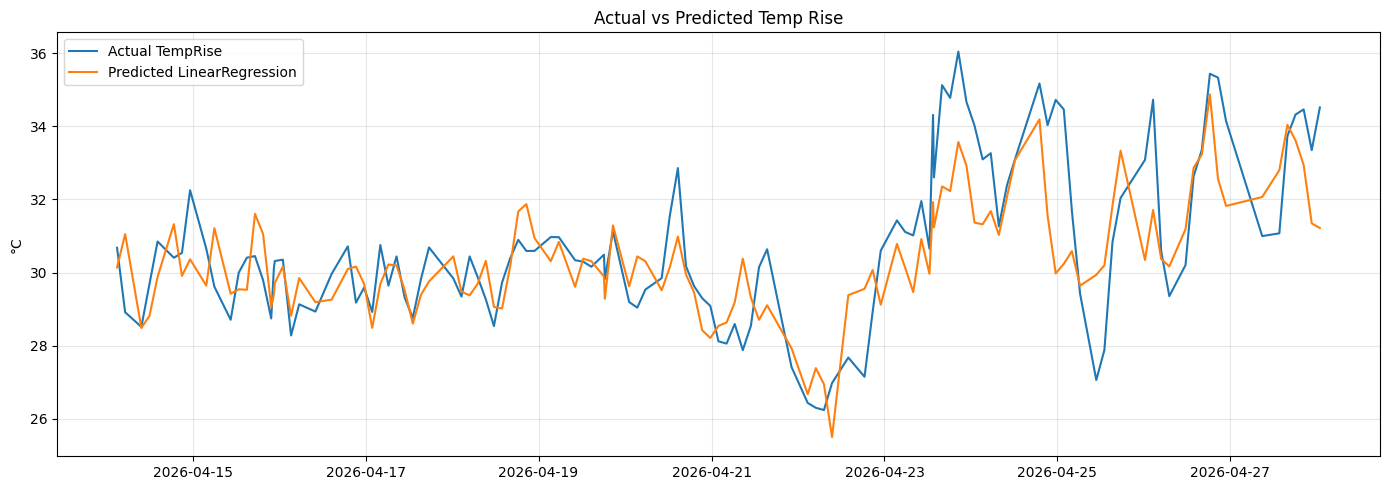

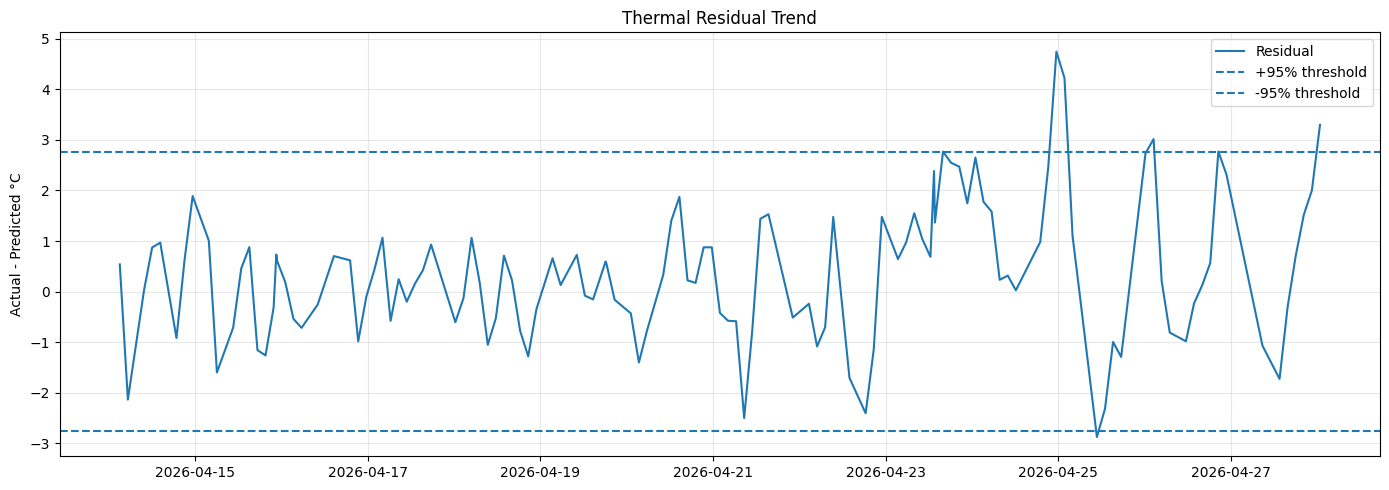


===== QUICK RESULTS =====
Date range: 2026-01-29 00:36:00 to 2026-04-28 10:42:00
Rows analyzed: 697
Average MW: 110.92
Average MVAr: -21.46
Average winding avg: 41.3 °C
Max winding: 54.89 °C
Average winding spread: 3.31 °C
Max winding spread: 17.03 °C
Average core: 42.57 °C
Average bearing max: 69.28 °C
Average water deltaT: 4.13 °C
Average cooling index: 0.2675
Average health score: 95.92
Best ML model: LinearRegression
Residual alarm threshold: 2.766 °C
Residual alarm events: 7

Files saved in: /content/UNIT2_generator_general_analysis_outputs

Done.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
    XGB_AVAILABLE = True
except Exception:
    XGB_AVAILABLE = False


# =========================================================
# 1. FILE PATHS
# =========================================================

base = Path("/content")

files = {
    "electric": base / "UNIT2_electric_28_4_2026_R2.csv",
    "cool": base / "UNIT2_cool_28_4_2026_R2.csv",
    "winding1": base / "UNIT2_winding1_28_4_2026_R2.csv",
    "winding2": base / "UNIT2_winding2_28_4_2026_R2.csv",
    "core": base / "UNIT2_Core_Pad_28_4_2026_R2.csv",
    "pad": base / "UNIT2_Pad_Pad_28_4_2026_R2.csv",
    "air": base / "UNIT2_Air_Pad_28_4_2026_R2.csv",
}

output_dir = Path("UNIT2_generator_general_analysis_outputs")
output_dir.mkdir(exist_ok=True)


# =========================================================
# 2. READ FILES
# =========================================================

def read_clean(path):
    df = pd.read_csv(path, encoding="utf-8", sep=",")
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.contains("^Unnamed")]
    df["Timestamp"] = pd.to_datetime(df["Timestamp"], errors="coerce")
    df = df.dropna(subset=["Timestamp"])
    df = df.sort_values("Timestamp").reset_index(drop=True)

    for c in df.columns:
        if c != "Timestamp":
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df


dfs = {name: read_clean(path) for name, path in files.items()}

print("Loaded files:")
for name, d in dfs.items():
    print(name, d.shape)


# =========================================================
# 3. MERGE ALL FILES BY TIMESTAMP
# =========================================================

df = dfs["electric"].copy()

for name in ["cool", "winding1", "winding2", "core", "pad", "air"]:
    df = pd.merge_asof(
        df.sort_values("Timestamp"),
        dfs[name].sort_values("Timestamp"),
        on="Timestamp",
        direction="nearest",
        tolerance=pd.Timedelta("10min"),
        suffixes=("", f"_{name}")
    )

print("Merged shape:", df.shape)


# =========================================================
# 4. AUTO-DETECT SENSOR GROUPS
# =========================================================

mw_col = "Active_power(MW)"
mvar_col = "Reactive_power(Mvar)"

voltage_cols = [c for c in df.columns if "Voltage" in c or "VOLTAGE" in c]
current_cols = [c for c in df.columns if "CURRENT PHASE" in c]
field_current_col = "FIELD CURRENT"
field_voltage_col = "FIELD VOLTAGE"

winding_cols = [c for c in df.columns if "STATOR WINDING" in c]
core_cols = [c for c in df.columns if "STATOR  CORE" in c or "STATOR CORE" in c]

upper_bearing_cols = [c for c in df.columns if "UPPER" in c and "BEARING" in c and "TEMP" in c]
lower_bearing_cols = [c for c in df.columns if "LOWER" in c and "BEARING" in c and "TEMP" in c]
thrust_bearing_cols = [c for c in df.columns if "THRUST" in c and "BEARING" in c and "TEMP" in c]
bearing_cols = upper_bearing_cols + lower_bearing_cols + thrust_bearing_cols

hot_air_cols = [c for c in df.columns if "HOT AIR" in c]
cold_air_cols = [c for c in df.columns if "COLD AIR" in c]

water_in_col = "GENERATOR COOLING WATER INLET TEMP"
water_out_col = "GENERATOR COOLING WATER OUTLET TEMP"
water_flow_col = "COOLING WATER FLOW"
water_pressure_col = "COOLING WATER PRESSURE"

print("\nDetected winding sensors:", len(winding_cols))
print(winding_cols)
print("\nDetected core sensors:", len(core_cols))
print(core_cols)
print("\nDetected bearing/pad sensors:", len(bearing_cols))
print(bearing_cols)
print("\nDetected hot air sensors:", hot_air_cols)
print("Detected cold air sensors:", cold_air_cols)


# =========================================================
# 5. BASIC CLEANING
# =========================================================

required = [mw_col, mvar_col] + winding_cols

missing_required = [c for c in required if c not in df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

df = df.dropna(subset=[mw_col, mvar_col])
df = df[df[mw_col] > 20].copy()

df["MW_diff_abs"] = df[mw_col].diff().abs()
analysis_df = df[
    (df[mw_col] > 20) &
    (df["MW_diff_abs"].fillna(0) < 15)
].copy()

analysis_df = analysis_df.sort_values("Timestamp").reset_index(drop=True)


# =========================================================
# 6. ELECTRICAL FEATURES
# =========================================================

analysis_df["MW"] = analysis_df[mw_col]
analysis_df["MVAr"] = analysis_df[mvar_col]
analysis_df["MVAr_abs"] = analysis_df["MVAr"].abs()

if len(current_cols) >= 3:
    analysis_df["I_mean"] = analysis_df[current_cols].mean(axis=1)
    analysis_df["I_max"] = analysis_df[current_cols].max(axis=1)
    analysis_df["I_min"] = analysis_df[current_cols].min(axis=1)
    analysis_df["I_mean_sq"] = analysis_df["I_mean"] ** 2
    analysis_df["Copper_loss_proxy"] = (analysis_df[current_cols] ** 2).sum(axis=1)
    analysis_df["I_imbalance_fast_pct"] = np.where(
        analysis_df["I_mean"] != 0,
        (analysis_df["I_max"] - analysis_df["I_min"]) / analysis_df["I_mean"] * 100,
        np.nan
    )

if len(voltage_cols) >= 3:
    analysis_df["V_mean_kV"] = analysis_df[voltage_cols].mean(axis=1)

if field_current_col in analysis_df.columns:
    analysis_df["Field_Current"] = analysis_df[field_current_col]
    analysis_df["Field_Current_sq"] = analysis_df["Field_Current"] ** 2
else:
    analysis_df["Field_Current"] = np.nan

if field_voltage_col in analysis_df.columns:
    analysis_df["Field_Voltage"] = analysis_df[field_voltage_col]
else:
    analysis_df["Field_Voltage"] = np.nan

analysis_df["MVA"] = np.sqrt(analysis_df["MW"]**2 + analysis_df["MVAr"]**2)
analysis_df["PF_abs"] = np.where(
    analysis_df["MVA"] != 0,
    abs(analysis_df["MW"]) / analysis_df["MVA"],
    np.nan
)

analysis_df["PF_dev"] = 1 - analysis_df["PF_abs"]
analysis_df["MW_x_MVAr"] = analysis_df["MW"] * analysis_df["MVAr_abs"]


# =========================================================
# 7. WINDING THERMAL FEATURES
# =========================================================

analysis_df["Winding_Avg"] = analysis_df[winding_cols].mean(axis=1)
analysis_df["Winding_Max"] = analysis_df[winding_cols].max(axis=1)
analysis_df["Winding_Min"] = analysis_df[winding_cols].min(axis=1)
analysis_df["Winding_Spread"] = analysis_df["Winding_Max"] - analysis_df["Winding_Min"]
analysis_df["Winding_Std"] = analysis_df[winding_cols].std(axis=1)
analysis_df["Winding_Hotspot_Sensor"] = analysis_df[winding_cols].idxmax(axis=1)

temp_dev_abs = analysis_df[winding_cols].sub(analysis_df["Winding_Avg"], axis=0).abs()
analysis_df["Worst_Winding_Deviation"] = temp_dev_abs.max(axis=1)
analysis_df["Worst_Winding_Deviation_Sensor"] = temp_dev_abs.idxmax(axis=1)


# =========================================================
# 8. CORE / BEARING / AIR / WATER FEATURES
# =========================================================

if core_cols:
    analysis_df["Core_Avg"] = analysis_df[core_cols].mean(axis=1)
    analysis_df["Core_Max"] = analysis_df[core_cols].max(axis=1)
    analysis_df["Core_Spread"] = analysis_df[core_cols].max(axis=1) - analysis_df[core_cols].min(axis=1)
else:
    analysis_df["Core_Avg"] = np.nan
    analysis_df["Core_Max"] = np.nan
    analysis_df["Core_Spread"] = np.nan

if bearing_cols:
    analysis_df["Bearing_Avg"] = analysis_df[bearing_cols].mean(axis=1)
    analysis_df["Bearing_Max"] = analysis_df[bearing_cols].max(axis=1)
else:
    analysis_df["Bearing_Avg"] = np.nan
    analysis_df["Bearing_Max"] = np.nan

if upper_bearing_cols:
    analysis_df["Upper_Bearing_Max"] = analysis_df[upper_bearing_cols].max(axis=1)
if lower_bearing_cols:
    analysis_df["Lower_Bearing_Max"] = analysis_df[lower_bearing_cols].max(axis=1)
if thrust_bearing_cols:
    analysis_df["Thrust_Bearing_Max"] = analysis_df[thrust_bearing_cols].max(axis=1)

if hot_air_cols:
    analysis_df["Hot_Air_Avg"] = analysis_df[hot_air_cols].mean(axis=1)
else:
    analysis_df["Hot_Air_Avg"] = np.nan

if cold_air_cols:
    analysis_df["Cold_Air_Avg"] = analysis_df[cold_air_cols].mean(axis=1)
else:
    analysis_df["Cold_Air_Avg"] = np.nan

analysis_df["Air_DeltaT"] = analysis_df["Hot_Air_Avg"] - analysis_df["Cold_Air_Avg"]

if water_in_col in analysis_df.columns:
    analysis_df["Water_Inlet"] = analysis_df[water_in_col]
else:
    analysis_df["Water_Inlet"] = np.nan

if water_out_col in analysis_df.columns:
    analysis_df["Water_Outlet"] = analysis_df[water_out_col]
else:
    analysis_df["Water_Outlet"] = np.nan

if water_flow_col in analysis_df.columns:
    analysis_df["Water_Flow"] = analysis_df[water_flow_col]
else:
    analysis_df["Water_Flow"] = np.nan

if water_pressure_col in analysis_df.columns:
    analysis_df["Water_Pressure"] = analysis_df[water_pressure_col]
else:
    analysis_df["Water_Pressure"] = np.nan

analysis_df["Water_DeltaT"] = analysis_df["Water_Outlet"] - analysis_df["Water_Inlet"]

analysis_df["Water_Flow_kg_s"] = analysis_df["Water_Flow"] * 1000 / 3600
analysis_df["Cooling_Heat_Removal_kW"] = (
    analysis_df["Water_Flow_kg_s"] * 4.186 * analysis_df["Water_DeltaT"]
)

analysis_df["Cooling_kW_per_MW"] = analysis_df["Cooling_Heat_Removal_kW"] / analysis_df["MW"]

analysis_df["TempRise_Avg_vs_Water"] = analysis_df["Winding_Avg"] - analysis_df["Water_Inlet"]
analysis_df["TempRise_Max_vs_Water"] = analysis_df["Winding_Max"] - analysis_df["Water_Inlet"]
analysis_df["TempRise_Avg_vs_ColdAir"] = analysis_df["Winding_Avg"] - analysis_df["Cold_Air_Avg"]

analysis_df["Cooling_Index_Water"] = analysis_df["TempRise_Avg_vs_Water"] / analysis_df["MW"]
analysis_df["Cooling_Index_Air"] = analysis_df["TempRise_Avg_vs_ColdAir"] / analysis_df["MW"]


# =========================================================
# 9. THERMAL INERTIA FEATURES
# =========================================================

for lag in [1, 2, 3, 6]:
    analysis_df[f"TempRise_lag{lag}"] = analysis_df["TempRise_Avg_vs_Water"].shift(lag)

for lag in [1, 2, 3]:
    analysis_df[f"MW_lag{lag}"] = analysis_df["MW"].shift(lag)
    analysis_df[f"MVAr_lag{lag}"] = analysis_df["MVAr"].shift(lag)
    analysis_df[f"Field_Current_lag{lag}"] = analysis_df["Field_Current"].shift(lag)
    if "I_mean" in analysis_df.columns:
        analysis_df[f"I_mean_lag{lag}"] = analysis_df["I_mean"].shift(lag)

analysis_df["TempRise_ewm"] = analysis_df["TempRise_Avg_vs_Water"].ewm(span=10, adjust=False).mean().shift(1)

analysis_df["dMW"] = analysis_df["MW"].diff()
analysis_df["dMVAr"] = analysis_df["MVAr"].diff()
analysis_df["dField_Current"] = analysis_df["Field_Current"].diff()


# =========================================================
# 10. BINS
# =========================================================

analysis_df["MW_bin_10"] = pd.cut(analysis_df["MW"], bins=np.arange(20, 181, 10), right=False)
analysis_df["MVAr_bin_10"] = pd.cut(analysis_df["MVAr"], bins=np.arange(-100, 101, 10), right=False)
analysis_df["Water_Inlet_bin"] = pd.cut(analysis_df["Water_Inlet"], bins=np.arange(0, 40, 2), right=False)

analysis_df["High_MVAr_Zone"] = analysis_df["MVAr_abs"] > analysis_df["MVAr_abs"].quantile(0.90)


# =========================================================
# 11. HEALTH SCORE
# =========================================================

def score_low_good(value, good, bad):
    if pd.isna(value):
        return np.nan
    if value <= good:
        return 100
    if value >= bad:
        return 0
    return 100 * (bad - value) / (bad - good)

analysis_df["Score_Winding_Max"] = analysis_df["Winding_Max"].apply(lambda x: score_low_good(x, 65, 95))
analysis_df["Score_Winding_Spread"] = analysis_df["Winding_Spread"].apply(lambda x: score_low_good(x, 3, 12))
analysis_df["Score_Core"] = analysis_df["Core_Max"].apply(lambda x: score_low_good(x, 60, 90))
analysis_df["Score_Bearing"] = analysis_df["Bearing_Max"].apply(lambda x: score_low_good(x, 70, 90))
analysis_df["Score_Cooling_Index"] = analysis_df["Cooling_Index_Water"].apply(lambda x: score_low_good(x, 0.25, 0.50))

analysis_df["Generator_Thermal_Health_Score"] = analysis_df[
    [
        "Score_Winding_Max",
        "Score_Winding_Spread",
        "Score_Core",
        "Score_Bearing",
        "Score_Cooling_Index",
    ]
].mean(axis=1)


# =========================================================
# 12. PLOT FUNCTIONS
# =========================================================

def save_time(y_cols, labels, ylabel, title, filename):
    plt.figure(figsize=(14, 5))
    for col, label in zip(y_cols, labels):
        if col in analysis_df.columns:
            plt.plot(analysis_df["Timestamp"], analysis_df[col], label=label)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_scatter(x, y, xlabel, ylabel, title, filename):
    plot_df = analysis_df[[x, y]].dropna()
    plt.figure(figsize=(8, 6))
    plt.scatter(plot_df[x], plot_df[y], s=18, alpha=0.65)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()

def save_scatter_colored(x, y, c, xlabel, ylabel, clabel, title, filename):
    plot_df = analysis_df[[x, y, c]].dropna()
    plt.figure(figsize=(8, 6))
    sc = plt.scatter(plot_df[x], plot_df[y], c=plot_df[c], s=18, alpha=0.7)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    cb = plt.colorbar(sc)
    cb.set_label(clabel)
    plt.tight_layout()
    plt.savefig(output_dir / filename, dpi=200)
    plt.show()


# =========================================================
# 13. GENERAL PLOTS
# =========================================================

save_time(
    ["MW", "MVAr"],
    ["MW", "MVAr"],
    "Power",
    "Active and Reactive Power Trend",
    "01_power_trend.png"
)

save_time(
    ["Winding_Avg", "Winding_Max", "Core_Avg", "Bearing_Max"],
    ["Winding Avg", "Winding Max", "Core Avg", "Bearing Max"],
    "Temperature °C",
    "Generator Thermal Trend",
    "02_generator_thermal_trend.png"
)

save_time(
    ["Winding_Spread"],
    ["Winding Spread"],
    "°C",
    "Winding Temperature Spread Trend",
    "03_winding_spread_trend.png"
)

save_time(
    ["Water_Inlet", "Water_Outlet", "Water_DeltaT"],
    ["Water Inlet", "Water Outlet", "Water DeltaT"],
    "°C",
    "Cooling Water Temperature Trend",
    "04_cooling_water_trend.png"
)

save_time(
    ["Cold_Air_Avg", "Hot_Air_Avg", "Air_DeltaT"],
    ["Cold Air Avg", "Hot Air Avg", "Air DeltaT"],
    "°C",
    "Cooling Air Temperature Trend",
    "05_air_temperature_trend.png"
)

save_time(
    ["Generator_Thermal_Health_Score"],
    ["Thermal Health Score"],
    "Score",
    "Generator Thermal Health Score",
    "06_health_score.png"
)

save_scatter("MW", "Winding_Avg", "MW", "Winding Avg °C", "Winding Avg vs MW", "07_winding_avg_vs_MW.png")
save_scatter("MW", "Winding_Max", "MW", "Winding Max °C", "Winding Max vs MW", "08_winding_max_vs_MW.png")
save_scatter("MW", "Winding_Spread", "MW", "Winding Spread °C", "Winding Spread vs MW", "09_winding_spread_vs_MW.png")
save_scatter("MW", "Water_DeltaT", "MW", "Water DeltaT °C", "Cooling Water DeltaT vs MW", "10_water_deltaT_vs_MW.png")
save_scatter("Water_Flow", "Water_DeltaT", "Water Flow", "Water DeltaT °C", "Water DeltaT vs Flow", "11_water_deltaT_vs_flow.png")
save_scatter("Water_Inlet", "Winding_Avg", "Water Inlet °C", "Winding Avg °C", "Winding Avg vs Water Inlet", "12_winding_vs_water_inlet.png")
save_scatter("Cold_Air_Avg", "Winding_Avg", "Cold Air Avg °C", "Winding Avg °C", "Winding Avg vs Cold Air", "13_winding_vs_cold_air.png")
save_scatter("Air_DeltaT", "Winding_Avg", "Air DeltaT °C", "Winding Avg °C", "Winding Avg vs Air DeltaT", "14_winding_vs_air_deltaT.png")
save_scatter("Core_Avg", "Winding_Avg", "Core Avg °C", "Winding Avg °C", "Winding vs Core", "15_winding_vs_core.png")

save_scatter_colored(
    "MW", "TempRise_Avg_vs_Water", "MVAr",
    "MW", "Temp Rise above Water °C", "MVAr",
    "Temp Rise vs MW colored by MVAr",
    "16_temprise_vs_MW_colored_by_MVAr.png"
)

save_scatter_colored(
    "MW", "TempRise_Avg_vs_Water", "Water_Inlet",
    "MW", "Temp Rise above Water °C", "Water Inlet °C",
    "Temp Rise vs MW colored by Water Inlet",
    "17_temprise_vs_MW_colored_by_water.png"
)

save_scatter_colored(
    "MW", "Winding_Spread", "MVAr",
    "MW", "Winding Spread °C", "MVAr",
    "Winding Spread vs MW colored by MVAr",
    "18_spread_vs_MW_colored_by_MVAr.png"
)


# =========================================================
# 14. SAME CONDITION SUMMARY
# =========================================================

same_condition_summary = analysis_df.groupby(
    ["MW_bin_10", "MVAr_bin_10", "Water_Inlet_bin"],
    observed=True
).agg(
    Count=("Timestamp", "count"),
    MW_mean=("MW", "mean"),
    MVAr_mean=("MVAr", "mean"),
    Water_Inlet_mean=("Water_Inlet", "mean"),
    Winding_Avg_mean=("Winding_Avg", "mean"),
    Winding_Max_mean=("Winding_Max", "mean"),
    Winding_Spread_mean=("Winding_Spread", "mean"),
    Core_Avg_mean=("Core_Avg", "mean"),
    Bearing_Max_mean=("Bearing_Max", "mean"),
    Water_DeltaT_mean=("Water_DeltaT", "mean"),
    Water_Flow_mean=("Water_Flow", "mean"),
    Cooling_Index_mean=("Cooling_Index_Water", "mean"),
    Health_Score_mean=("Generator_Thermal_Health_Score", "mean"),
).reset_index()

same_condition_summary = same_condition_summary[same_condition_summary["Count"] >= 5]


# =========================================================
# 15. HOTSPOT SENSOR SUMMARY
# =========================================================

hotspot_count = analysis_df["Winding_Hotspot_Sensor"].value_counts().reset_index()
hotspot_count.columns = ["Sensor", "Hotspot_Count"]

winding_sensor_summary = pd.DataFrame({
    "Sensor": winding_cols,
    "Mean_Temp": [analysis_df[c].mean() for c in winding_cols],
    "Max_Temp": [analysis_df[c].max() for c in winding_cols],
    "Std_Temp": [analysis_df[c].std() for c in winding_cols],
})

winding_sensor_summary = winding_sensor_summary.merge(
    hotspot_count, on="Sensor", how="left"
).fillna(0)

winding_sensor_summary = winding_sensor_summary.sort_values(
    ["Hotspot_Count", "Max_Temp"],
    ascending=False
)


# =========================================================
# 16. ML THERMAL MODEL
# =========================================================

candidate_features = [
    "MW", "MVAr", "MVAr_abs", "PF_abs", "PF_dev",
    "I_mean", "I_mean_sq", "Copper_loss_proxy",
    "Field_Current", "Field_Current_sq",
    "Water_Inlet", "Water_Flow", "Water_Pressure",
    "Cold_Air_Avg", "Hot_Air_Avg", "Air_DeltaT",
    "TempRise_lag1", "TempRise_lag2", "TempRise_lag3", "TempRise_lag6",
    "TempRise_ewm",
    "MW_lag1", "MW_lag2", "MW_lag3",
    "MVAr_lag1", "MVAr_lag2", "MVAr_lag3",
    "dMW", "dMVAr", "dField_Current",
]

features = [c for c in candidate_features if c in analysis_df.columns]
target_col = "TempRise_Avg_vs_Water"

model_df = analysis_df.dropna(subset=features + [target_col]).copy()

X = model_df[features]
y = model_df[target_col]

split_idx = int(len(model_df) * 0.80)

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

test_df = model_df.iloc[split_idx:].copy()

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    )
}

if XGB_AVAILABLE:
    models["XGBoost"] = XGBRegressor(
        n_estimators=400,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.85,
        colsample_bytree=0.85,
        random_state=42,
        objective="reg:squarederror"
    )

metrics_rows = []

for name, model in models.items():
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    metrics_rows.append({
        "Model": name,
        "Train_R2": r2_score(y_train, train_pred),
        "Test_R2": r2_score(y_test, test_pred),
        "Train_MAE_C": mean_absolute_error(y_train, train_pred),
        "Test_MAE_C": mean_absolute_error(y_test, test_pred),
        "Train_RMSE_C": np.sqrt(mean_squared_error(y_train, train_pred)),
        "Test_RMSE_C": np.sqrt(mean_squared_error(y_test, test_pred)),
    })

    test_df[f"{name}_Pred"] = test_pred
    test_df[f"{name}_Residual"] = y_test - test_pred

metrics_df = pd.DataFrame(metrics_rows).sort_values("Test_R2", ascending=False)

best_model_name = metrics_df.iloc[0]["Model"]
best_res_col = f"{best_model_name}_Residual"
best_pred_col = f"{best_model_name}_Pred"

print("\nModel performance:")
print(metrics_df.round(4))
print("\nBest model:", best_model_name)

res_thr = test_df[best_res_col].abs().quantile(0.95)
test_df["Residual_Alarm"] = test_df[best_res_col].abs() > res_thr

residual_events = test_df[test_df["Residual_Alarm"]].copy()


# =========================================================
# 17. RESIDUAL PLOTS
# =========================================================

plt.figure(figsize=(14, 5))
plt.plot(test_df["Timestamp"], test_df[target_col], label="Actual TempRise")
plt.plot(test_df["Timestamp"], test_df[best_pred_col], label=f"Predicted {best_model_name}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Actual vs Predicted Temp Rise")
plt.ylabel("°C")
plt.tight_layout()
plt.savefig(output_dir / "19_actual_vs_predicted_temprise.png", dpi=200)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(test_df["Timestamp"], test_df[best_res_col], label="Residual")
plt.axhline(res_thr, linestyle="--", label="+95% threshold")
plt.axhline(-res_thr, linestyle="--", label="-95% threshold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Thermal Residual Trend")
plt.ylabel("Actual - Predicted °C")
plt.tight_layout()
plt.savefig(output_dir / "20_thermal_residual_trend.png", dpi=200)
plt.show()


# =========================================================
# 18. DAILY SUMMARY
# =========================================================

analysis_df["Date"] = analysis_df["Timestamp"].dt.date

daily_summary = analysis_df.groupby("Date").agg(
    MW_mean=("MW", "mean"),
    MW_max=("MW", "max"),
    MVAr_mean=("MVAr", "mean"),
    PF_mean=("PF_abs", "mean"),
    Winding_Avg_mean=("Winding_Avg", "mean"),
    Winding_Max_max=("Winding_Max", "max"),
    Winding_Spread_mean=("Winding_Spread", "mean"),
    Winding_Spread_max=("Winding_Spread", "max"),
    Core_Avg_mean=("Core_Avg", "mean"),
    Bearing_Max_mean=("Bearing_Max", "mean"),
    Water_Inlet_mean=("Water_Inlet", "mean"),
    Water_DeltaT_mean=("Water_DeltaT", "mean"),
    Water_Flow_mean=("Water_Flow", "mean"),
    Cooling_Index_mean=("Cooling_Index_Water", "mean"),
    Health_Score_mean=("Generator_Thermal_Health_Score", "mean"),
).reset_index()


# =========================================================
# 19. SAVE OUTPUTS
# =========================================================

analysis_df.to_csv(output_dir / "merged_general_analysis_dataset.csv", index=False)
same_condition_summary.to_csv(output_dir / "same_condition_summary.csv", index=False)
winding_sensor_summary.to_csv(output_dir / "winding_hotspot_sensor_summary.csv", index=False)
daily_summary.to_csv(output_dir / "daily_summary.csv", index=False)
metrics_df.to_csv(output_dir / "model_metrics.csv", index=False)
test_df.to_csv(output_dir / "model_test_predictions.csv", index=False)
residual_events.to_csv(output_dir / "thermal_residual_alarm_events.csv", index=False)

with pd.ExcelWriter(output_dir / "UNIT2_Generator_General_Analysis.xlsx", engine="openpyxl") as writer:
    analysis_df.to_excel(writer, sheet_name="Merged_Analysis", index=False)
    same_condition_summary.to_excel(writer, sheet_name="Same_Condition", index=False)
    winding_sensor_summary.to_excel(writer, sheet_name="Winding_Hotspots", index=False)
    daily_summary.to_excel(writer, sheet_name="Daily_Summary", index=False)
    metrics_df.to_excel(writer, sheet_name="Model_Metrics", index=False)
    residual_events.to_excel(writer, sheet_name="Residual_Alarms", index=False)


# =========================================================
# 20. QUICK RESULTS
# =========================================================

print("\n===== QUICK RESULTS =====")
print("Date range:", analysis_df["Timestamp"].min(), "to", analysis_df["Timestamp"].max())
print("Rows analyzed:", len(analysis_df))
print("Average MW:", round(analysis_df["MW"].mean(), 2))
print("Average MVAr:", round(analysis_df["MVAr"].mean(), 2))
print("Average winding avg:", round(analysis_df["Winding_Avg"].mean(), 2), "°C")
print("Max winding:", round(analysis_df["Winding_Max"].max(), 2), "°C")
print("Average winding spread:", round(analysis_df["Winding_Spread"].mean(), 2), "°C")
print("Max winding spread:", round(analysis_df["Winding_Spread"].max(), 2), "°C")
print("Average core:", round(analysis_df["Core_Avg"].mean(), 2), "°C")
print("Average bearing max:", round(analysis_df["Bearing_Max"].mean(), 2), "°C")
print("Average water deltaT:", round(analysis_df["Water_DeltaT"].mean(), 2), "°C")
print("Average cooling index:", round(analysis_df["Cooling_Index_Water"].mean(), 4))
print("Average health score:", round(analysis_df["Generator_Thermal_Health_Score"].mean(), 2))
print("Best ML model:", best_model_name)
print("Residual alarm threshold:", round(res_thr, 3), "°C")
print("Residual alarm events:", len(residual_events))
print("\nFiles saved in:", output_dir.resolve())
print("\nDone.")